# NB03: Biomedical GraphRAG Layer (NetworkX + Louvain)

## What
Build a biomedical entity co-occurrence graph from chunk metadata, detect communities, and demonstrate GraphRAG local/global search context creation.

## Why
Vector retrieval finds semantically similar chunks. Graph retrieval adds explicit multi-hop concept connectivity, which is critical for biomedical relationships.

## When
Run whenever chunk/entity artifacts change.

## Technology Choice
- **Chosen**: NetworkX + Louvain (`python-louvain`)
- **Why not Neo4j**: excellent production graph database, but extra infra complexity for tutorial scope.
- **Why not iGraph**: faster for very large graphs, but less ergonomic with our Python-first workflow.
- **Why not GNN stack now**: learned graph representations are powerful but beyond this baseline GraphRAG objective.

In [1]:
# Input: notebook runtime and persisted chunk artifacts.
# Output: imports and deterministic environment.
# Logic: initialize dependencies and paths.
# Complexity: O(1).
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.chunking import load_chunks
from src.config import settings
from src.graph_builder import (
    build_entity_graph,
    community_summaries,
    community_summary_text,
    concept_id_from_query,
    detect_communities,
    graph_statistics,
    local_graph_expansion,
    rank_communities_for_query,
)
from src.utils import save_json, save_plot, timed_block

## Step 1: Load Chunk Records

### Why
Chunks already contain concept IDs and mention text, making graph construction straightforward.

In [2]:
# Input: `data/processed/medmentions_chunks.parquet`.
# Output: list of chunk records.
# Logic: deserialize persisted chunk artifacts.
# Complexity: O(number_of_chunks).
chunks = load_chunks()
print(f"Loaded chunks: {len(chunks):,}")

Loaded chunks: 5,098


## Step 2: Build Entity Co-occurrence Graph

### Graph Definition
- **Nodes**: UMLS concept IDs.
- **Edges**: two concepts co-occur in same chunk.
- **Edge weight**: co-occurrence frequency.

### Tradeoff
Co-occurrence captures topical relation, not causality.

In [3]:
# Input: chunk records with concept IDs.
# Output: weighted undirected entity graph.
# Logic: count node frequencies and pairwise co-occurrences.
# Complexity: O(sum(entities_per_chunk^2)).
with timed_block("Build graph"):
    graph = build_entity_graph(chunks, min_entity_frequency=2, min_edge_weight=1)

stats = graph_statistics(graph)
pd.DataFrame([stats])

2026-06-19 21:58:26 | INFO | Graph built with 15454 nodes and 2191052 edges
2026-06-19 21:58:26 | INFO | build_entity_graph completed in 5.57s
2026-06-19 21:58:26 | INFO | Build graph completed in 5.57s


,nodes,edges,density,num_components,largest_component,avg_degree,median_degree
0,15454,2191052,0.01835,1,15454,283.557914,117.0


## Step 3: Visualize Graph-Level Structure

### Why
Degree distribution and sampled topology help validate graph quality.

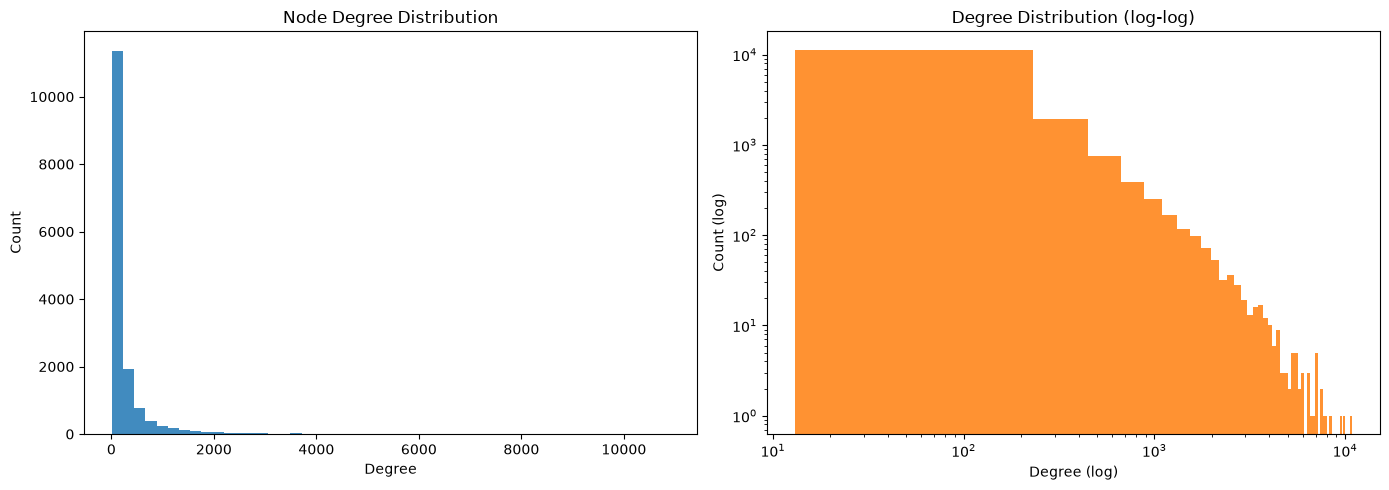

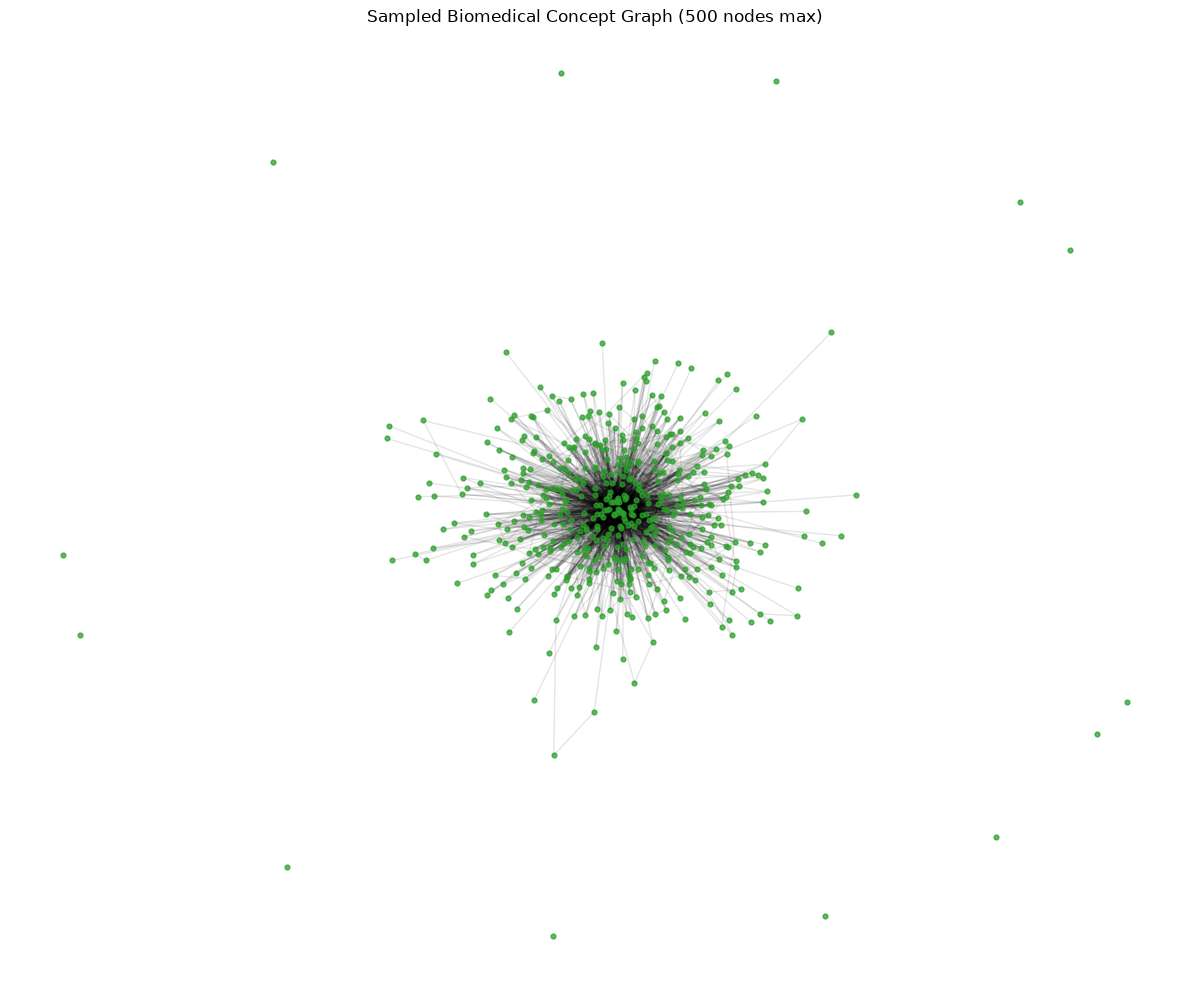

In [4]:
# Input: graph object.
# Output: degree histogram + sampled graph figure.
# Logic: analyze degree statistics and draw spring-layout sample.
# Complexity: O(V + E) for stats, O(sample_edges) for drawing.
degrees = np.array([deg for _, deg in graph.degree()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(degrees, bins=50, color="#1f77b4", alpha=0.85)
axes[0].set_title("Node Degree Distribution")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")

axes[1].hist(degrees, bins=50, color="#ff7f0e", alpha=0.85)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Degree Distribution (log-log)")
axes[1].set_xlabel("Degree (log)")
axes[1].set_ylabel("Count (log)")

save_plot(settings.figures_dir / "nb03_degree_distributions.png")
plt.show()

# Draw sampled subgraph for readability.
rng = np.random.default_rng(settings.random_seed)
sample_nodes = list(graph.nodes())
if len(sample_nodes) > 500:
    sample_nodes = rng.choice(sample_nodes, size=500, replace=False).tolist()
sample_graph = graph.subgraph(sample_nodes)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(sample_graph, seed=settings.random_seed, k=0.35)
nx.draw_networkx_nodes(sample_graph, pos, node_size=12, alpha=0.75, node_color="#2ca02c")
nx.draw_networkx_edges(sample_graph, pos, alpha=0.10)
plt.title("Sampled Biomedical Concept Graph (500 nodes max)")
plt.axis("off")
save_plot(settings.figures_dir / "nb03_graph_sample.png")
plt.show()

## Step 4: Community Detection (Louvain)

### What
Louvain identifies densely connected communities, enabling GraphRAG global-search summaries.

### Why chosen
Fast, practical, and widely used for large sparse graphs.

In [5]:
# Input: graph.
# Output: node -> community partition mapping and summary table.
# Logic: Louvain partition + top-entity summarization.
# Complexity: approximately near-linear for sparse graphs.
with timed_block("Louvain community detection"):
    partition = detect_communities(graph, resolution=1.0)

summaries = community_summaries(graph, partition, top_entities=12)
summary_df = pd.DataFrame(
    [
        {
            "community_id": item["community_id"],
            "size": item["size"],
            "num_edges": item["num_edges"],
            "top_entity": item["top_entities"][0]["label"] if item["top_entities"] else "",
        }
        for item in summaries
    ]
)

summary_df.head(15)

2026-06-19 22:00:05 | INFO | Detected 7 communities
2026-06-19 22:00:05 | INFO | detect_communities completed in 96.10s
2026-06-19 22:00:05 | INFO | Louvain community detection completed in 96.10s


,community_id,size,num_edges,top_entity
0,1,6133,538645,patients
1,2,4060,260743,expression
2,0,3109,190544,qualitative
3,3,2110,64982,genes
4,4,23,123,low-iodine intake
5,6,12,31,atrophy
6,5,7,21,RUG


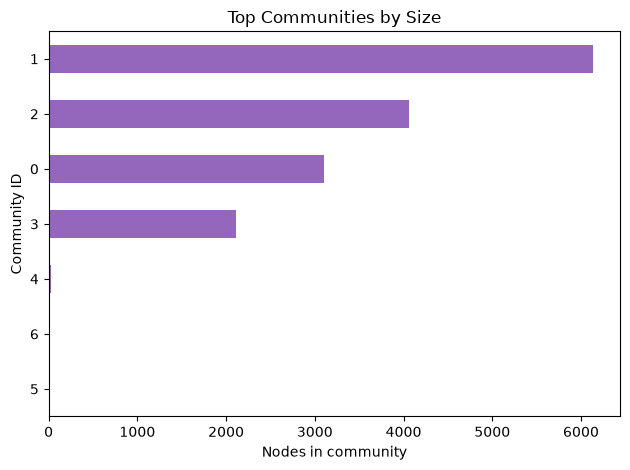

In [6]:
# Input: community summary table.
# Output: community size chart.
# Logic: visualize top communities by node count.
# Complexity: O(number_of_communities).
plot_df = summary_df.head(15).sort_values("size")
ax = plot_df.plot(
    kind="barh",
    x="community_id",
    y="size",
    color="#9467bd",
    legend=False,
    title="Top Communities by Size",
)
ax.set_xlabel("Nodes in community")
ax.set_ylabel("Community ID")
save_plot(settings.figures_dir / "nb03_community_sizes.png")
plt.show()

## Step 5: GraphRAG Local Search Example

### What
Local search expands from query-matched entities by graph hops.

### Why
Captures nearby biomedical concepts that pure vector retrieval can miss.

In [7]:
# Input: demo biomedical query.
# Output: extracted concept IDs + expanded local neighborhood.
# Logic: map query to concept IDs then perform k-hop expansion.
# Complexity: O(neighborhood edges visited).
demo_query = "What does the literature say about diabetes and insulin resistance?"
query_concept_ids = concept_id_from_query(demo_query, chunks)
local_context = local_graph_expansion(graph, query_concept_ids, hops=2)

print("Demo query:", demo_query)
print("Matched concept IDs:", query_concept_ids[:10])
print("Local nodes:", len(local_context.get("nodes", [])))
print("Local edges:", len(local_context.get("edges", [])))

Demo query: What does the literature say about diabetes and insulin resistance?
Matched concept IDs: ['C0023866', 'C0011847', 'C4281815', 'C0021641', 'C0034693', 'C0034721', 'C0439227', 'C0021655']
Local nodes: 15454
Local edges: 2191052


## Step 6: GraphRAG Global Search Example

### What
Global search selects relevant communities and transforms them into textual summaries for LLM context.

### Why
Community-level context helps answer broader thematic queries.

In [8]:
# Input: query concept IDs, partition, and community summaries.
# Output: top community summaries as text.
# Logic: rank communities by concept overlap and render text summaries.
# Complexity: O(number_of_communities).
selected_communities = rank_communities_for_query(query_concept_ids, partition, summaries, top_k=3)
for idx, community in enumerate(selected_communities, start=1):
    print(f"\n--- Community Context {idx} ---")
    print(community_summary_text(community)[:1000])


--- Community Context 1 ---
Community 2 (size=4060, edges=260743):
Key biomedical concepts:
- expression (concept_id=C1171362, freq=362, centrality=0.630)
- induced (concept_id=C0205263, freq=409, centrality=0.619)
- cells (concept_id=C0007634, freq=426, centrality=0.592)
- increased (concept_id=C0205217, freq=612, centrality=0.563)
- human (concept_id=C0086418, freq=437, centrality=0.529)
- effect (concept_id=C1280500, freq=617, centrality=0.527)
- levels (concept_id=C0441889, freq=554, centrality=0.524)
- investigated (concept_id=C1292732, freq=599, centrality=0.498)
- reduced (concept_id=C0392756, freq=520, centrality=0.492)
- mechanisms (concept_id=C0441712, freq=336, centrality=0.485)
- expression (concept_id=C0017262, freq=284, centrality=0.461)
- inhibition (concept_id=C3463820, freq=224, centrality=0.454)

--- Community Context 2 ---
Community 1 (size=6133, edges=538645):
Key biomedical concepts:
- patients (concept_id=C0030705, freq=1653, centrality=0.839)
- study (concept_id

## Step 7: Persist Graph Artifacts

### Why
NB04 and NB05 require graph + communities without recomputation.

In [9]:
# Input: graph and community artifacts.
# Output: pickle/json persisted graph assets.
# Logic: serialize reusable artifacts.
# Complexity: O(V + E).
with (settings.graph_dir / "entity_graph.pkl").open("wb") as f:
    pickle.dump(graph, f)

save_json(partition, settings.graph_dir / "community_partition.json")
save_json(summaries, settings.graph_dir / "community_summaries.json")

summary_df.to_csv(settings.tables_dir / "nb03_community_summary.csv", index=False)

print("Saved graph artifacts to:", settings.graph_dir)

Saved graph artifacts to: /home/ahmad/AI/Medical-Research-GraphRAG/graphs


## Notebook Recap

You now have:
1. A biomedical concept graph from real MedMentions entities.
2. Louvain communities for GraphRAG global search.
3. Demonstrated local and global graph-context generation.
4. Persisted graph assets for retrieval and agentic orchestration.

Next: NB04 builds ChromaDB and Pinecone GraphRAG retrieval and benchmarks them side-by-side.